In [ ]:
import yfinance as yf                              # pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm                        # pip install statsmodels
from statsmodels.tsa.stattools import adfuller     
from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
# Load and Inspect
#   Fetch data 
btc = yf.download("BTC-USD", start="2024-01-01", end="2026-03-31")
spx = yf.download("^GSPC", start="2024-01-01", end="2026-03-31")

#   Load and align data into dataframe, keep only overlapping trading days
df = btc[['Close']].rename(columns={'Close': 'BTC'}) \
    .join(spx[['Close']].rename(columns={'Close': 'SPX'}), how='inner')

#   Inspect
print("--------------------------------------------")
print(df.shape)
print("--------------------------------------------")
print(df.info())
print("--------------------------------------------")
print(df.describe())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

--------------------------------------------
(562, 2)
--------------------------------------------
<class 'pandas.DataFrame'>
DatetimeIndex: 562 entries, 2024-01-02 to 2026-03-30
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (BTC, BTC-USD)  562 non-null    float64
 1   (SPX, ^GSPC)    562 non-null    float64
dtypes: float64(2)
memory usage: 13.2 KB
None
--------------------------------------------
Price             BTC          SPX
Ticker        BTC-USD        ^GSPC
count      562.000000   562.000000
mean     83038.116048  5928.051793
std      21502.232258   627.130307
min      39507.367188  4688.680176
25%      65361.158203  5446.977661
50%      84457.699219  5907.984863
75%     101586.880859  6481.474976
max     124752.531250  6978.600098


In [ ]:
# Data Surgery (Cleaning)
#   Drop duplicates & missing values
df = df[~df.index.duplicated(keep='first')]
df = df.dropna()

#   Enforce naming consistency
df.columns = ['BTC', 'SPX']
df.sort_index(inplace=True)

#   Enforce data type
df = df.astype(float)

#   Sync timezones
df.index = df.index.tz_localize(None)

#   Convert prices into returns
returns = np.log(df).diff().dropna()

In [12]:
# Export Cleaned Data
df.to_csv("out.csv")    

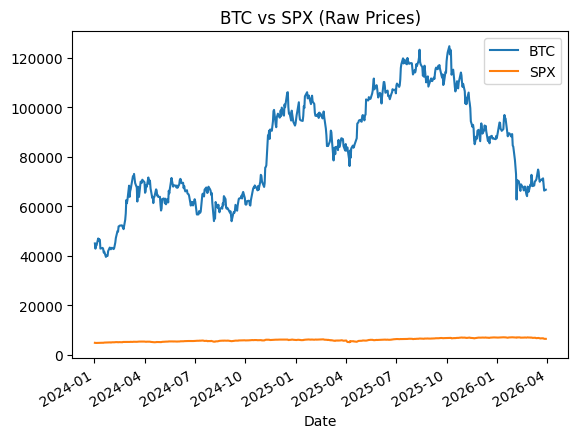

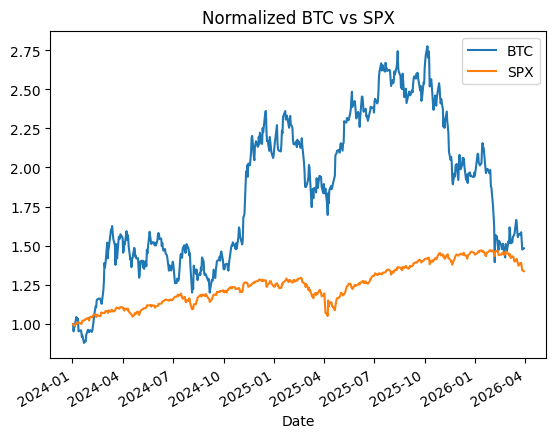

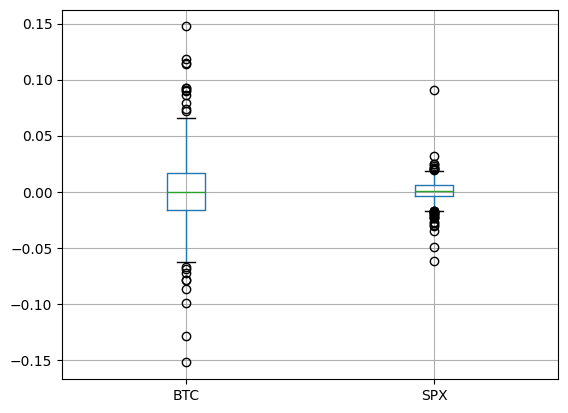

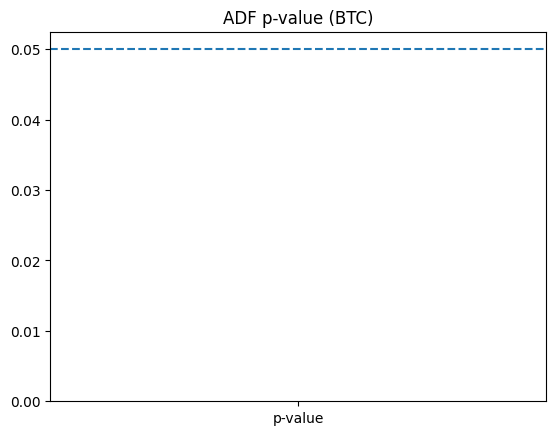

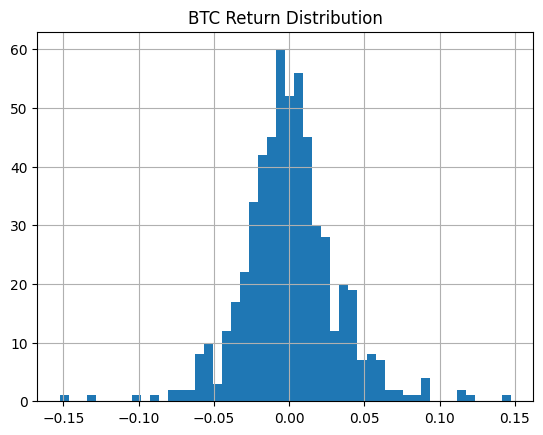

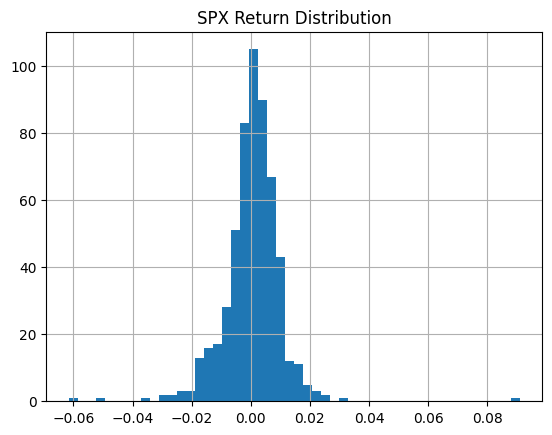

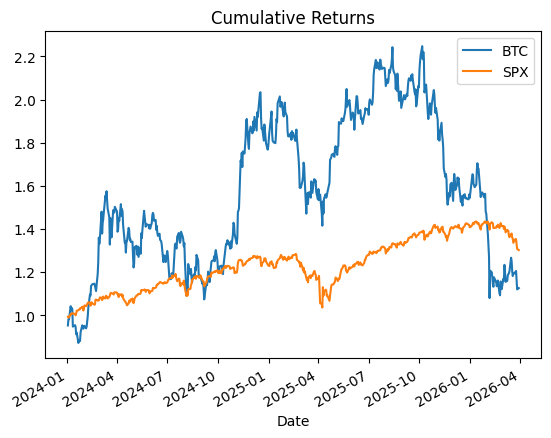

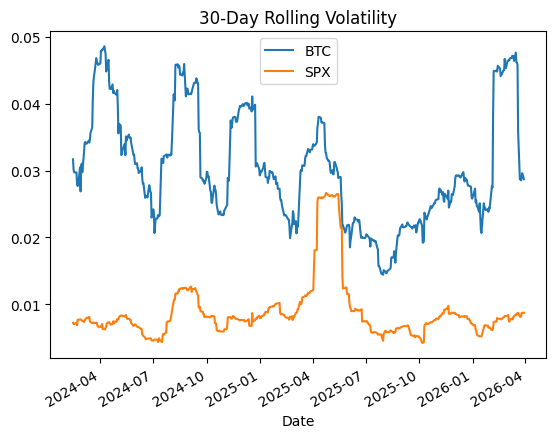

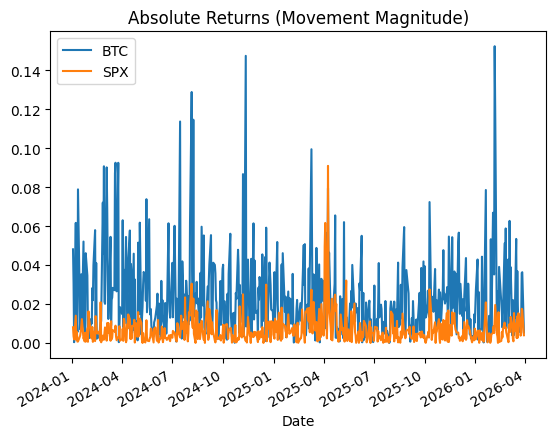

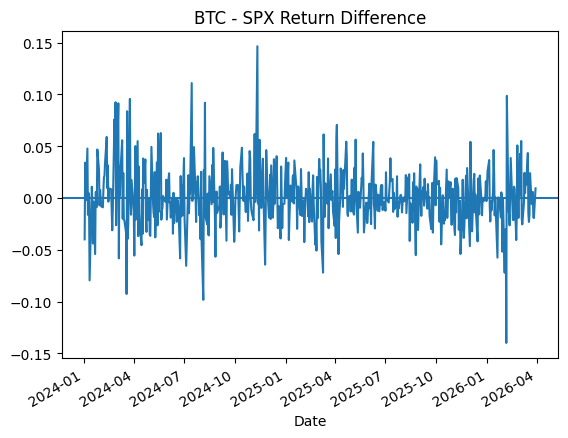

In [17]:
# Exploratory Plotting
#   Compare raw data
df.plot(title="BTC vs SPX (Raw Prices)")
plt.show()

#   Compare normalized data
norm = df / df.iloc[0]
norm.plot(title="Normalized BTC vs SPX")
plt.show()

#   Check for outliers
returns.boxplot()
plt.show()

#   Check stationarity, p-value < 0.05
result = adfuller(returns['BTC'])
pval = result[1]

plt.bar(["p-value"], [pval])
plt.axhline(0.05, linestyle='--')
plt.title("ADF p-value (BTC)")
plt.show()

#   Check return distribution for skewness
returns['BTC'].hist(bins=50)
plt.title("BTC Return Distribution")
plt.show()

returns['SPX'].hist(bins=50)
plt.title("SPX Return Distribution")
plt.show()

#   Show growth trajectory
(1 + returns).cumprod().plot(title="Cumulative Returns")
plt.show()

#   Show rolling volatility
returns.rolling(30).std().plot(title="30-Day Rolling Volatility")
plt.show()

#   Compare intensity of movements
returns.abs().plot(title="Absolute Returns (Movement Magnitude)")
plt.show()

#   Show difference series
diff = returns['BTC'] - returns['SPX']
diff.plot(title="BTC - SPX Return Difference")
plt.axhline(0)
plt.show()

In [ ]:
# The Analysis (The "Engine")
#   Cross-correlation function (CCF)
max_lag = 30  # days
lags = range(-max_lag, max_lag+1)

corrs = [returns['BTC'].shift(lag).corr(returns['SPX']) for lag in lags]

#   Lagged Regression
max_lag = 10
betas = []

for lag in range(1, max_lag+1):
    X = returns['BTC'].shift(lag).dropna()
    Y = returns['SPX'].loc[X.index]
    
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit()
    
    betas.append(model.params[1])

#   Granger Causality
results = grangercausalitytests(returns[['SPX', 'BTC']], maxlag=10, verbose=False)

pvals = [results[i+1][0]['ssr_ftest'][1] for i in range(10)]